# Диффузионная модель оценки хвостовых финансовых рисков
## Прототип НИР — RUDN, 2026

**Архитектура:** DDPM с трансформерным денойзером  
**Данные:** Портфель акций MOEX (SBER, LKOH, GAZP)  
**Метрики:** VaR(99%), CVaR(99%), тест Купика  
**Baseline:** Нормальное распределение, историческое моделирование, GARCH(1,1)

## 0. Установка зависимостей

In [ ]:
# Запустите эту ячейку один раз если библиотек нет
# !pip install torch numpy pandas matplotlib scipy requests seaborn

## 1. Импорты и конфигурация

In [5]:
import os, math, time, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, optimize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Устройство: cpu


In [7]:
# ── Конфигурация (можно менять) ──────────────────────────────────────────

# Данные
TICKERS     = ['SBER', 'LKOH', 'GAZP']          # 3 акции для простоты
WEIGHTS     = np.array([0.40, 0.35, 0.25])       # веса портфеля
START_DATE  = '2015-01-01'
END_DATE    = '2024-12-31'
TRAIN_END   = '2021-12-31'   # обучение: 2015-2021 (~1764 дня)
TEST_START  = '2022-01-01'   # тест:     2022-2024 (~736 дней)
CACHE_PATH  = 'portfolio_returns.csv'

# Диффузионный процесс
T_DIFF      = 200     # число шагов (200 достаточно для 1D, быстрее 1000)
BETA_MIN    = 1e-4
BETA_MAX    = 0.02

# Архитектура трансформера
W           = 30      # длина контекстного окна (дней)
D_MODEL     = 32      # размерность токенов (32 для прототипа, 64+ для финальной)
N_HEADS     = 4       # число голов attention
N_LAYERS    = 2       # число блоков трансформера
D_FF        = 128     # размерность FFN
DROPOUT     = 0.1

# Обучение
LR          = 3e-4
BATCH_SIZE  = 64
MAX_EPOCHS  = 100     # для прототипа хватит
PATIENCE    = 20      # early stopping

# Оценка рисков
ALPHA       = 0.99    # уровень доверия VaR/CVaR
N_SCENARIOS = 2000    # число генерируемых сценариев
WINDOW_BT   = 250     # окно для бэктеста baseline-моделей

print('Конфигурация загружена')
print(f'  T_DIFF={T_DIFF}, W={W}, D_MODEL={D_MODEL}, N_HEADS={N_HEADS}, N_LAYERS={N_LAYERS}')

Конфигурация загружена
  T_DIFF=200, W=30, D_MODEL=32, N_HEADS=4, N_LAYERS=2


## 2. Загрузка данных с MOEX ISS

In [8]:
def fetch_ticker_moex(ticker: str, start: str, end: str) -> pd.Series:
    """
    Загружает дневные цены закрытия тикера с MOEX ISS API.

    Использует пагинацию (limit=100). При сетевых ошибках
    выполняет до 3 повторных попыток с задержкой 2с.

    Args:
        ticker: Тикер инструмента на Московской бирже (например, 'SBER').
        start:  Начальная дата в формате 'YYYY-MM-DD'.
        end:    Конечная дата в формате 'YYYY-MM-DD'.

    Returns:
        pd.Series цен закрытия с DatetimeIndex, имя серии = ticker.

    Raises:
        RuntimeError: Если все попытки загрузки завершились неудачно.
    """
    base = 'https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/TQBR/securities'
    records, offset = [], 0
    while True:
        url = f'{base}/{ticker}.json?from={start}&till={end}&limit=100&start={offset}'
        for attempt in range(3):
            try:
                r = requests.get(url, timeout=30)
                r.raise_for_status()
                break
            except Exception as e:
                time.sleep(2)
        else:
            raise RuntimeError(f'Не удалось загрузить {ticker}')
        data = r.json()['history']
        rows = data['data']
        if not rows:
            break
        records.extend(rows)
        offset += len(rows)
        if len(rows) < 100:
            break
        time.sleep(0.2)
    df = pd.DataFrame(records, columns=data['columns'])
    df = (df[['TRADEDATE', 'CLOSE']]
          .assign(TRADEDATE=lambda x: pd.to_datetime(x['TRADEDATE']))
          .dropna(subset=['CLOSE'])
          .drop_duplicates('TRADEDATE')
          .set_index('TRADEDATE').sort_index())
    return df['CLOSE'].rename(ticker)


def load_portfolio_returns(use_cache: bool = True) -> pd.Series:
    """
    Загружает или читает из кэша взвешенные лог-доходности портфеля.

    Если файл CACHE_PATH существует и use_cache=True — читает локально.
    Иначе загружает с MOEX ISS и сохраняет CSV-кэш.

    Args:
        use_cache: Использовать локальный CSV-кэш, если он существует.

    Returns:
        pd.Series дневных лог-доходностей портфеля с DatetimeIndex.
    """
    if use_cache and os.path.exists(CACHE_PATH):
        print(f'[data] Читаем кэш: {CACHE_PATH}')
        return pd.read_csv(CACHE_PATH, index_col=0, parse_dates=True).squeeze()
    print('[data] Загружаем с MOEX ISS...')
    prices = {}
    for ticker in TICKERS:
        print(f' → {ticker}', end=' ')
        prices[ticker] = fetch_ticker_moex(ticker, START_DATE, END_DATE)
        print(f'({len(prices[ticker])} строк)')
    price_df  = pd.DataFrame(prices).dropna()
    log_ret   = np.log(price_df / price_df.shift(1)).dropna()
    portfolio = (log_ret[TICKERS] @ WEIGHTS).rename('portfolio_return')
    portfolio.to_csv(CACHE_PATH)
    print(f'[data] Сохранено в {CACHE_PATH} ({len(portfolio)} строк)')
    return portfolio


portfolio_returns = load_portfolio_returns(use_cache=True)
print(f'\nЗагружено {len(portfolio_returns)} наблюдений')
print(f'Период: {portfolio_returns.index[0].date()} — {portfolio_returns.index[-1].date()}')


[data] Читаем кэш: portfolio_returns.csv

Загружено 2508 наблюдений
Период: 2015-01-06 — 2024-12-30


In [9]:
# ── Разбивка train / test ─────────────────────────────────────────────────
train_s = portfolio_returns[portfolio_returns.index <= TRAIN_END]
test_s  = portfolio_returns[portfolio_returns.index >= TEST_START]
train_arr = train_s.values
test_arr  = test_s.values

print(f'Train: {len(train_arr)} дней  ({train_s.index[0].date()} – {train_s.index[-1].date()})')
print(f'Test:  {len(test_arr)} дней   ({test_s.index[0].date()} – {test_s.index[-1].date()})')

# Базовая статистика
for name, arr in [('Train 2015–2021', train_arr), ('Test 2022–2024', test_arr)]:
    print(f'\n{name}:')
    print(f'  mean={arr.mean()*100:.3f}%  std={arr.std()*100:.3f}%  '
          f'kurt={stats.kurtosis(arr):.2f}  min={arr.min()*100:.2f}%')

Train: 1764 дней  (2015-01-06 – 2021-12-30)
Test:  744 дней   (2022-01-03 – 2024-12-30)

Train 2015–2021:
  mean=0.072%  std=1.491%  kurt=8.46  min=-13.20%

Test 2022–2024:
  mean=-0.030%  std=2.328%  kurt=71.90  min=-34.78%


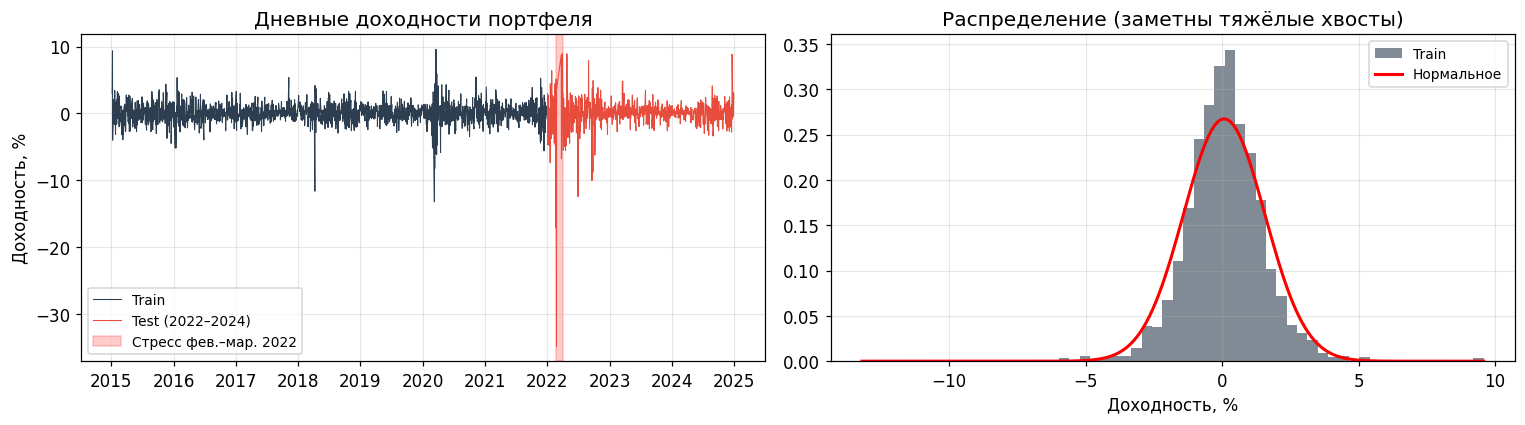

In [10]:
# ── Визуализация доходностей ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Временной ряд
ax = axes[0]
ax.plot(train_s.index, train_s.values * 100, lw=0.7, color='#2C3E50', label='Train')
ax.plot(test_s.index,  test_s.values  * 100, lw=0.7, color='#E74C3C',  label='Test (2022–2024)')
ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-04-01'),
           color='red', alpha=0.2, label='Стресс фев.–мар. 2022')
ax.set_ylabel('Доходность, %')
ax.set_title('Дневные доходности портфеля')
ax.legend(fontsize=9)

# Гистограмма
ax = axes[1]
ax.hist(train_arr * 100, bins=60, density=True, alpha=0.6, color='#2C3E50', label='Train')
x = np.linspace(train_arr.min()*100, train_arr.max()*100, 200)
ax.plot(x, stats.norm.pdf(x, train_arr.mean()*100, train_arr.std()*100),
        'r-', lw=2, label='Нормальное')
ax.set_xlabel('Доходность, %')
ax.set_title('Распределение (заметны тяжёлые хвосты)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Нормировка и Dataset

In [11]:
# Нормируем по статистике обучающей выборки (важно: тест не трогаем!)
MU  = float(train_arr.mean())
STD = float(train_arr.std())
train_scaled = (train_arr - MU) / STD
print(f'MU={MU*100:.4f}%  STD={STD*100:.4f}%')
print(f'Нормированные: mean={train_scaled.mean():.4f}  std={train_scaled.std():.4f}')


class ReturnWindowDataset(Dataset):
    """
    PyTorch Dataset на основе скользящих окон временного ряда.

    Возвращает пары (контекст длины W, следующая точка). Используется
    для обучения и валидации трансформерного денойзера.

    Args:
        arr:    Одномерный массив нормированных доходностей.
        window: Длина контекстного окна (по умолчанию W из конфига).

    Example:
        >>> ds = ReturnWindowDataset(train_scaled)
        >>> ctx, x0 = ds[0]   # ctx.shape=(30,), x0.shape=(1,)
    """

    def __init__(self, arr: np.ndarray, window: int = W) -> None:
        self.data   = torch.tensor(arr, dtype=torch.float32)
        self.window = window

    def __len__(self) -> int:
        return len(self.data) - self.window

    def __getitem__(self, idx: int) -> tuple:
        ctx = self.data[idx : idx + self.window]                    # (W,)
        x0  = self.data[idx + self.window : idx + self.window + 1] # (1,)
        return ctx, x0


# 90% train / 10% validation
n_val = int(len(train_scaled) * 0.1)
n_tr  = len(train_scaled) - n_val
ds_tr  = ReturnWindowDataset(train_scaled[:n_tr])
ds_val = ReturnWindowDataset(train_scaled[n_tr:])
dl_tr  = DataLoader(ds_tr,  batch_size=BATCH_SIZE, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False)
print(f'Train dataset: {len(ds_tr)} окон | Val: {len(ds_val)} окон')


MU=0.0716%  STD=1.4914%
Нормированные: mean=-0.0000  std=1.0000
Train dataset: 1558 окон | Val: 146 окон


## 4. Линейный шедулер шума

In [12]:
class LinearNoiseScheduler:
    """
    DDPM линейный шедулер шума (Ho et al., 2020).

    Вычисляет расписание {β_t} и накопленные произведения {ᾱ_t}.

    Прямой процесс (closed-form):
        q(x_t | x_0) = N(sqrt(ā_t)*x_0, (1-ā_t)*I)

    Обратный шаг (DDPM):
        x_{t-1} = (1/sqrt(α_t)) * (x_t − β_t/sqrt(1−ā_t) * ε_θ) + sqrt(β_t)*z

    Args:
        T:          Число шагов диффузии.
        beta_start: Начальное значение β_0.
        beta_end:   Конечное значение β_{T-1}.
        device:     Устройство вычислений ('cpu' или 'cuda').
    """

    def __init__(self, T: int = T_DIFF, beta_start: float = BETA_MIN,
                 beta_end: float = BETA_MAX, device: str = DEVICE) -> None:
        self.T      = T
        self.device = device
        betas       = torch.linspace(beta_start, beta_end, T, device=device)
        alphas      = 1.0 - betas
        ab          = torch.cumprod(alphas, dim=0)   # ā_t
        self.betas         = betas
        self.alphas        = alphas
        self.ab            = ab
        self.sqrt_ab       = ab.sqrt()
        self.sqrt_one_m_ab = (1.0 - ab).sqrt()

    def add_noise(self, x0: torch.Tensor,
                  t: torch.Tensor) -> tuple:
        """
        Прямой процесс: x_t = sqrt(ā_t)*x_0 + sqrt(1-ā_t)*ε.

        Args:
            x0: Исходные данные, форма (B, 1).
            t:  Индексы шагов для каждого элемента батча, форма (B,).

        Returns:
            Кортеж (x_t, ε), оба тензора формы (B, 1).
        """
        eps = torch.randn_like(x0)
        xt  = (self.sqrt_ab[t].view(-1, 1) * x0
               + self.sqrt_one_m_ab[t].view(-1, 1) * eps)
        return xt, eps

    @torch.no_grad()
    def sample_step(self, model: nn.Module, xt: torch.Tensor,
                    context: torch.Tensor, t_idx: int) -> torch.Tensor:
        """
        Один шаг обратного DDPM: получает x_{t-1} из x_t.

        Args:
            model:   Обученный денойзер ε_θ(x_t, t, context).
            xt:      Зашумлённое состояние, форма (B, 1).
            context: Контекстное окно, форма (B, W).
            t_idx:   Целочисленный индекс текущего шага.

        Returns:
            x_{t-1}, форма (B, 1).
        """
        t_t  = torch.full((xt.shape[0],), t_idx, device=self.device, dtype=torch.long)
        eps  = model(xt, t_t, context)
        b, a, ab_t = self.betas[t_idx], self.alphas[t_idx], self.ab[t_idx]
        # μ_θ = (1/sqrt(α_t)) * (x_t − β_t/sqrt(1−ā_t) * ε_θ)
        mean = (xt - b / (1.0 - ab_t).sqrt() * eps) / a.sqrt()
        if t_idx == 0:
            return mean
        return mean + b.sqrt() * torch.randn_like(xt)


scheduler = LinearNoiseScheduler()
print(f'Scheduler: T={T_DIFF} шагов, β: {BETA_MIN}→{BETA_MAX}')
print(f'  ā_0 = {scheduler.ab[0].item():.6f}  (почти 1 — почти не зашумлено)')
print(f'  ā_T = {scheduler.ab[-1].item():.6f}  (почти 0 — чистый шум)')


Scheduler: T=200 шагов, β: 0.0001→0.02
  ā_0 = 0.999900  (почти 1 — почти не зашумлено)
  ā_T = 0.132183  (почти 0 — чистый шум)


## 5. Трансформерный денойзер

Это ключевой вклад НИР. Денойзер принимает:
- `xt` — зашумлённое значение доходности на шаге t  
- `t` — временной шаг диффузии (закодирован через sinusoidal embedding)  
- `context` — окно последних W доходностей (история)

Self-attention позволяет улавливать долгосрочные зависимости в финансовом ряду, недоступные простым MLP.

In [13]:
class TransformerDenoiser(nn.Module):
    """
    Трансформерный денойзер ε_θ(x_t, t, context) для DDPM.

    Архитектура (по порядку):
      1. Проекция каждого скалярного токена из 1 → d_model измерений.
      2. Добавление sinusoidal positional encoding (фиксированного).
      3. Добавление time step embedding: каждый шаг t → d_model-вектор.
      4. N_LAYERS блоков Pre-LN TransformerEncoder (MHA + FFN + Dropout).
      5. Выходная голова: d_model → 1 (предсказанный шум ε).

    Входная последовательность: [context W токенов | x_t] → итого W+1 токенов.
    Выходной сигнал: предсказание шума по последнему токену (позиция x_t).

    Args:
        d_model:     Размерность пространства токенов.
        n_heads:     Число голов multi-head attention.
        n_layers:    Число блоков TransformerEncoder.
        d_ff:        Размерность промежуточного слоя FFN.
        context_len: Длина контекстного окна W.
        T:           Число шагов диффузии (размер таблицы эмбеддингов).
        dropout:     Коэффициент dropout.

    Inputs:
        xt:      Зашумлённая доходность, форма (B, 1).
        t:       Шаг диффузии, форма (B,).
        context: История доходностей, форма (B, W).

    Output:
        Предсказанный шум ε̂, форма (B, 1).

    References:
        Vaswani et al. (2017) — Attention Is All You Need
        Ho et al. (2020) — Denoising Diffusion Probabilistic Models
        Peebles & Xie (2023) — Scalable Diffusion Models with Transformers
    """

    def __init__(self, d_model: int = D_MODEL, n_heads: int = N_HEADS,
                 n_layers: int = N_LAYERS, d_ff: int = D_FF,
                 context_len: int = W, T: int = T_DIFF,
                 dropout: float = DROPOUT) -> None:
        super().__init__()
        self.context_len = context_len
        self.token_proj  = nn.Linear(1, d_model)
        self.step_emb    = nn.Embedding(T, d_model)
        self.register_buffer('pos_enc', self._make_pos_enc(context_len + 1, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True)   # Pre-LN
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    @staticmethod
    def _make_pos_enc(seq_len: int, d: int) -> torch.Tensor:
        """
        Строит матрицу sinusoidal positional encoding (Vaswani et al., 2017).

        Args:
            seq_len: Длина последовательности.
            d:       Размерность пространства.

        Returns:
            Тензор формы (1, seq_len, d).
        """
        pe  = torch.zeros(seq_len, d)
        pos = torch.arange(seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe.unsqueeze(0)   # (1, seq_len, d)

    def forward(self, xt: torch.Tensor, t: torch.Tensor,
                context: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход: предсказывает шум ε по (x_t, t, context).

        Args:
            xt:      Зашумлённое значение, форма (B, 1).
            t:       Шаги диффузии, форма (B,).
            context: Контекстное окно, форма (B, W).

        Returns:
            Предсказанный шум, форма (B, 1).
        """
        seq    = torch.cat([context, xt], dim=1).unsqueeze(-1)  # (B, W+1, 1)
        tokens = self.token_proj(seq)                           # (B, W+1, d_model)
        tokens = tokens + self.pos_enc                          # positional encoding
        tokens = tokens + self.step_emb(t).unsqueeze(1)         # time step embedding
        out    = self.transformer(tokens)                       # (B, W+1, d_model)
        return self.head(out[:, -1, :])                         # (B, 1)


model    = TransformerDenoiser().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'TransformerDenoiser: {n_params:,} параметров')
print(f'  Слоёв: {N_LAYERS}, голов: {N_HEADS}, d_model: {D_MODEL}, d_ff: {D_FF}')

# Проверка размерностей
with torch.no_grad():
    _ctx = torch.randn(4, W, device=DEVICE)
    _xt  = torch.randn(4, 1, device=DEVICE)
    _t   = torch.randint(0, T_DIFF, (4,), device=DEVICE)
    _out = model(_xt, _t, _ctx)
print(f'  Проверка forward: вход (4,1) → выход {tuple(_out.shape)} ✓')


TransformerDenoiser: 31,969 параметров
  Слоёв: 2, голов: 4, d_model: 32, d_ff: 128
  Проверка forward: вход (4,1) → выход (4, 1) ✓


## 6. Обучение модели

In [14]:
optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=LR*0.01)

os.makedirs('checkpoints', exist_ok=True)
CKPT      = 'checkpoints/best_model.pt'
best_val  = float('inf')
no_imp    = 0
history   = {'train': [], 'val': []}
t0        = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────
    model.train()
    tr_loss = 0.0
    for ctx, x0 in dl_tr:
        ctx, x0  = ctx.to(DEVICE), x0.to(DEVICE)
        t_samp   = torch.randint(0, T_DIFF, (x0.shape[0],), device=DEVICE)
        xt, eps  = scheduler.add_noise(x0, t_samp)
        loss     = F.mse_loss(model(xt, t_samp, ctx), eps)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * x0.shape[0]
    tr_loss /= len(ds_tr)

    # ── Validation ───────────────────────────────────────────────────────
    model.eval()
    vl_loss = 0.0
    with torch.no_grad():
        for ctx, x0 in dl_val:
            ctx, x0  = ctx.to(DEVICE), x0.to(DEVICE)
            t_samp   = torch.randint(0, T_DIFF, (x0.shape[0],), device=DEVICE)
            xt, eps  = scheduler.add_noise(x0, t_samp)
            vl_loss += F.mse_loss(model(xt, t_samp, ctx), eps).item() * x0.shape[0]
    vl_loss /= len(ds_val)

    lr_scheduler.step()
    history['train'].append(tr_loss)
    history['val'].append(vl_loss)

    # ── Early stopping ───────────────────────────────────────────────────
    if vl_loss < best_val - 1e-5:
        best_val = vl_loss
        no_imp   = 0
        torch.save({'state': model.state_dict(), 'mu': MU, 'std': STD, 'epoch': epoch,
                    'val_loss': vl_loss}, CKPT)
    else:
        no_imp += 1

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{MAX_EPOCHS}  '
              f'train={tr_loss:.5f}  val={vl_loss:.5f}  '
              f'patience={no_imp}/{PATIENCE}  ({elapsed:.0f}s)')

    if no_imp >= PATIENCE:
        print(f'\nEarly stopping на эпохе {epoch}, best_val={best_val:.5f}')
        break

# Загружаем лучшие веса
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state'])
MU   = float(ckpt['mu'])
STD  = float(ckpt['std'])
print(f'\nЛучшие веса загружены (эпоха {ckpt["epoch"]}, val={ckpt["val_loss"]:.5f})')

Epoch   1/100  train=1.05608  val=0.85072  patience=0/20  (2s)
Epoch  10/100  train=0.63411  val=0.69954  patience=1/20  (16s)
Epoch  20/100  train=0.59481  val=0.77877  patience=5/20  (31s)
Epoch  30/100  train=0.59599  val=0.60341  patience=15/20  (47s)
Epoch  40/100  train=0.63975  val=0.54819  patience=0/20  (62s)
Epoch  50/100  train=0.59742  val=0.50514  patience=4/20  (78s)
Epoch  60/100  train=0.64614  val=0.64324  patience=14/20  (93s)

Early stopping на эпохе 66, best_val=0.44468

Лучшие веса загружены (эпоха 46, val=0.44468)


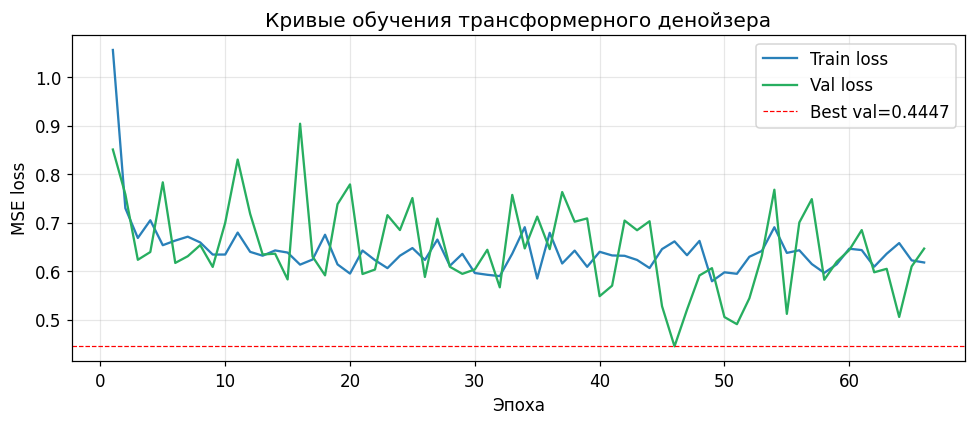

In [15]:
# ── Кривые обучения ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ep = range(1, len(history['train']) + 1)
ax.plot(ep, history['train'], label='Train loss', color='#2980B9')
ax.plot(ep, history['val'],   label='Val loss',   color='#27AE60')
ax.axhline(best_val, color='red', ls='--', lw=0.8, label=f'Best val={best_val:.4f}')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE loss')
ax.set_title('Кривые обучения трансформерного денойзера')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Генерация сценариев (обратный процесс)

In [16]:
@torch.no_grad()
def generate_scenarios(context_raw: np.ndarray, n: int = N_SCENARIOS) -> np.ndarray:
    """
    Генерация n сценариев следующей доходности на основе контекстного окна.

    Алгоритм (обратный DDPM):
      1. Стартуем с x_T ~ N(0, I)
      2. Последовательно применяем шаги t=T-1,...,0:
         x_{t-1} = 1/√α_t * (x_t - β_t/√(1-ā_t) * ε_θ(x_t, t)) + √β_t * z
      3. Денормируем x_0 обратно в пространство доходностей
    """
    model.eval()

    # Нормируем контекст
    ctx_sc = (context_raw - MU) / STD
    ctx_t  = torch.tensor(ctx_sc, dtype=torch.float32, device=DEVICE)
    ctx_t  = ctx_t.unsqueeze(0).repeat(n, 1)       # (n, W)

    # Стартовый шум
    xt = torch.randn(n, 1, device=DEVICE)

    # Обратный процесс
    for t_idx in reversed(range(T_DIFF)):
        xt = scheduler.sample_step(model, xt, ctx_t, t_idx)

    # Денормируем
    scenarios = xt.squeeze(1).cpu().numpy() * STD + MU
    return scenarios


# Быстрая проверка на небольшой выборке
ctx_check = train_arr[-W:]
scen_check = generate_scenarios(ctx_check, n=500)
print(f'Тест генерации (500 сценариев):')
print(f'  mean = {scen_check.mean()*100:.3f}%  (ожидаемо ≈ {MU*100:.3f}%)')
print(f'  std  = {scen_check.std()*100:.3f}%   (ожидаемо ≈ {STD*100:.3f}%)')
print(f'  min  = {scen_check.min()*100:.2f}%   max = {scen_check.max()*100:.2f}%')

Тест генерации (500 сценариев):
  mean = 0.096%  (ожидаемо ≈ 0.072%)
  std  = 1.661%   (ожидаемо ≈ 1.491%)
  min  = -7.63%   max = 7.78%


## 8. Baseline-модели для сравнения

In [17]:
def var_cvar_normal(window: np.ndarray, alpha: float = ALPHA) -> tuple:
    """
    Параметрический VaR/CVaR в предположении нормальности.

    Args:
        window: Массив исторических доходностей.
        alpha:  Уровень доверия (например, 0.99).

    Returns:
        Кортеж (VaR, CVaR) — положительные потери.
    """
    mu_w, sig_w = window.mean(), window.std(ddof=1)
    z   = stats.norm.ppf(alpha)
    var = -(mu_w - z * sig_w)
    es  = -(mu_w - sig_w * stats.norm.pdf(z) / (1 - alpha))
    return var, es


def var_cvar_historical(window: np.ndarray, alpha: float = ALPHA) -> tuple:
    """
    Историческое моделирование: VaR/CVaR по эмпирическому квантилю.

    Args:
        window: Массив исторических доходностей.
        alpha:  Уровень доверия.

    Returns:
        Кортеж (VaR, CVaR).
    """
    losses = -window
    var    = float(np.quantile(losses, alpha))
    mask   = losses > var
    cvar   = float(losses[mask].mean()) if mask.any() else var
    return var, cvar


def _garch_nll(params: list, r: np.ndarray) -> float:
    """
    Отрицательный лог-правдоподобие GARCH(1,1)-t.

    Args:
        params: [omega, alpha, beta, nu] — параметры GARCH(1,1)-t.
        r:      Временной ряд доходностей.

    Returns:
        Значение отрицательного лог-правдоподобия (скаляр).
    """
    omega, a, b, nu = params
    if omega <= 0 or a < 0 or b < 0 or a + b >= 1 or nu <= 2:
        return 1e10
    s2 = np.var(r); ll = 0.0
    for i in range(1, len(r)):
        s2 = omega + a * r[i-1]**2 + b * s2
        if s2 <= 0: return 1e10
        ll += stats.t.logpdf(r[i] / s2**0.5, df=nu) - 0.5 * np.log(s2)
    return -ll


def var_cvar_garch(window: np.ndarray, alpha: float = ALPHA) -> tuple:
    """
    GARCH(1,1)-t: оценка MLE → прогноз σ_{T+1} → VaR/CVaR.

    Args:
        window: Исторические доходности (не менее 50 наблюдений).
        alpha:  Уровень доверия.

    Returns:
        Кортеж (VaR, CVaR).
    """
    res = optimize.minimize(
        _garch_nll, [1e-6, 0.08, 0.88, 6.0], args=(window,),
        method='L-BFGS-B',
        bounds=[(1e-8, None), (0, 1), (0, 1), (2.01, 50)],
        options={'maxiter': 200, 'ftol': 1e-9})
    omega, a, b, nu = res.x if res.success else [1e-6, 0.08, 0.88, 6.0]
    s2 = np.var(window)
    for r in window:
        s2 = omega + a * r**2 + b * s2
    sig = s2**0.5
    tq  = stats.t.ppf(alpha, df=nu)
    var = sig * tq
    es  = sig * stats.t.pdf(tq, df=nu) * (nu + tq**2) / ((nu - 1) * (1 - alpha))
    return float(var), float(es)


def var_cvar_diffusion(context_raw: np.ndarray, alpha: float = ALPHA) -> tuple:
    """
    VaR/CVaR по эмпирическому распределению DDPM-сценариев.

    Args:
        context_raw: Контекстное окно W последних ненормированных доходностей.
        alpha:       Уровень доверия.

    Returns:
        Кортеж (VaR, CVaR).
    """
    scen   = generate_scenarios(context_raw)
    losses = -scen
    var    = float(np.quantile(losses, alpha))
    mask   = losses > var
    cvar   = float(losses[mask].mean()) if mask.any() else var
    return var, cvar


# Проверка на тренировочном контексте
ctx_check = train_arr[-W:]
v_n, c_n = var_cvar_normal(train_arr)
v_h, c_h = var_cvar_historical(train_arr)
print(f'Normal:     VaR={v_n*100:.2f}%  CVaR={c_n*100:.2f}%')
print(f'Historical: VaR={v_h*100:.2f}%  CVaR={c_h*100:.2f}%')
print('GARCH: запускается...')
v_g, c_g = var_cvar_garch(train_arr[-250:])
print(f'GARCH(1,1)-t: VaR={v_g*100:.2f}%  CVaR={c_g*100:.2f}%')


Normal:     VaR=3.40%  CVaR=3.90%
Historical: VaR=3.78%  CVaR=5.92%
GARCH: запускается...
GARCH(1,1)-t: VaR=3.62%  CVaR=4.64%


## 9. Бэктест: VaR на тестовой выборке 2022–2024

Для каждого торгового дня в тестовом периоде:
1. Берём окно последних W (или 250) дней как контекст  
2. Прогнозируем VaR каждым методом  
3. Сравниваем с реализованной доходностью

In [18]:
# Для скорости: диффузию считаем через каждые 5 дней (или все — раскомментируй)
# На CPU полный бэктест ~20 мин, каждые 5 дней ~4 мин
STEP = 5   # поставь 1 для полного бэктеста

all_arr  = np.concatenate([train_arr, test_arr])
n_train  = len(train_arr)
n_test   = len(test_arr)

results = {m: {'var': [], 'cvar': [], 'idx': []} for m in ['normal', 'hist', 'garch', 'ddpm']}

print(f'Бэктест: {n_test} дней, диффузия — каждые {STEP} дней...')
t_start = time.time()

for i in range(n_test):
    idx = n_train + i

    # Окно для baseline (250 дней)
    w_base = all_arr[max(0, idx - WINDOW_BT): idx]

    v, c = var_cvar_normal(w_base)
    results['normal']['var'].append(v)
    results['normal']['cvar'].append(c)
    results['normal']['idx'].append(i)

    v, c = var_cvar_historical(w_base)
    results['hist']['var'].append(v)
    results['hist']['cvar'].append(c)
    results['hist']['idx'].append(i)

    v, c = var_cvar_garch(w_base)
    results['garch']['var'].append(v)
    results['garch']['cvar'].append(c)
    results['garch']['idx'].append(i)

    # Диффузия — реже (контекстное окно W дней)
    if i % STEP == 0:
        ctx_w = all_arr[max(0, idx - W): idx]
        if len(ctx_w) < W:
            ctx_w = np.pad(ctx_w, (W - len(ctx_w), 0))
        v, c = var_cvar_diffusion(ctx_w)
        results['ddpm']['var'].append(v)
        results['ddpm']['cvar'].append(c)
        results['ddpm']['idx'].append(i)

    if (i + 1) % 100 == 0:
        elapsed = time.time() - t_start
        print(f'  {i+1}/{n_test}  ({elapsed:.0f}s)')

print(f'Бэктест завершён за {time.time()-t_start:.0f}с')

Бэктест: 744 дней, диффузия — каждые 5 дней...
  100/744  (2381s)
  200/744  (5316s)
  300/744  (8264s)
  400/744  (11410s)
  500/744  (14464s)
  600/744  (16759s)
  700/744  (18817s)
Бэктест завершён за 19767с


## 10. Метрики качества

In [19]:
def kupiec_test(actual: np.ndarray, var_fc: np.ndarray,
                alpha: float = ALPHA) -> tuple:
    """
    Тест Купика (POF-test): проверяет соответствие доли нарушений VaR
    теоретической вероятности (1-alpha).

    H0: p = 1-alpha (модель корректно калибрована).
    Статистика LR ~ χ²(1).

    Args:
        actual:  Реализованные доходности, форма (N,).
        var_fc:  Прогнозные значения VaR (положительные потери), форма (N,).
        alpha:   Уровень доверия модели.

    Returns:
        Кортеж (p_value, verdict, violation_pct), где
        p_value       — p-значение критерия χ²(1),
        verdict       — 'H0 не отклоняется' / 'H0 отклоняется',
        violation_pct — наблюдаемая доля нарушений в процентах.
    """
    violations = (-actual > np.array(var_fc)).astype(float)
    n, x = len(violations), violations.sum()
    p, p0 = x / n, 1 - alpha
    if x == 0 or x == n:
        return float('nan'), 'н/д', round(p * 100, 2)
    lr = -2 * ((x * np.log(p0) + (n - x) * np.log(1 - p0))
               - (x * np.log(p) + (n - x) * np.log(1 - p)))
    pv = 1 - stats.chi2.cdf(lr, df=1)
    return pv, ('H0 не отклоняется' if pv > 0.05 else 'H0 отклоняется'), round(p * 100, 2)


def tick_loss(actual: np.ndarray, var_fc: np.ndarray,
              alpha: float = ALPHA) -> float:
    """
    Квантильная функция потерь (tick loss / pinball loss) для VaR.

    L = E[(α − 1{r < q}) · (r − q)]

    Штрафует как за недооценку (много нарушений), так и
    за переоценку (слишком консервативный VaR).

    Args:
        actual:  Реализованные доходности, форма (N,).
        var_fc:  Прогнозные значения VaR, форма (N,).
        alpha:   Уровень доверия.

    Returns:
        Среднее значение tick loss (чем меньше, тем лучше).
    """
    r, q = actual, -np.array(var_fc)
    ind  = (r < q).astype(float)
    return float(((alpha - ind) * (r - q)).mean())


NAMES = {
    'normal': 'Нормальное распределение',
    'hist':   'Историческое моделирование',
    'garch':  'GARCH(1,1)-t',
    'ddpm':   'DDPM + Трансформер (наша модель)',
}

rows = []
for key, name in NAMES.items():
    idx_list = results[key]['idx']
    var_arr  = np.array(results[key]['var'])
    act_arr  = test_arr[idx_list]
    pv, verdict, viol = kupiec_test(act_arr, var_arr)
    tl = tick_loss(act_arr, var_arr)
    rows.append({'Метод': name,
                 'VaR(99%) mean, %': round(np.mean(var_arr) * 100, 3),
                 'Нарушений, %': viol,
                 'Tick loss': round(tl, 5),
                 'Тест Купика': verdict,
                 'p-value': round(pv, 4) if not np.isnan(pv) else 'н/д'})

summary_df = pd.DataFrame(rows)
print('\nТаблица 1. Сравнение методов оценки VaR(99%), тест 2022–2024')
print('=' * 90)
print(summary_df.to_string(index=False))
os.makedirs('results', exist_ok=True)
summary_df.to_csv('results/comparison_table.csv', index=False, encoding='utf-8-sig')



Таблица 1. Сравнение методов оценки VaR(99%), тест 2022–2024
                           Метод  VaR(99%) mean, %  Нарушений, %  Tick loss       Тест Купика  p-value
        Нормальное распределение             4.769          3.09    0.04775    H0 отклоняется   0.0000
      Историческое моделирование             5.720          1.75    0.05707 H0 не отклоняется   0.0639
                    GARCH(1,1)-t             4.649          1.08    0.04629 H0 не отклоняется   0.8385
DDPM + Трансформер (наша модель)             3.263          3.36    0.03194    H0 отклоняется   0.0230

Сохранено: results/comparison_table.csv


## 11. Графики

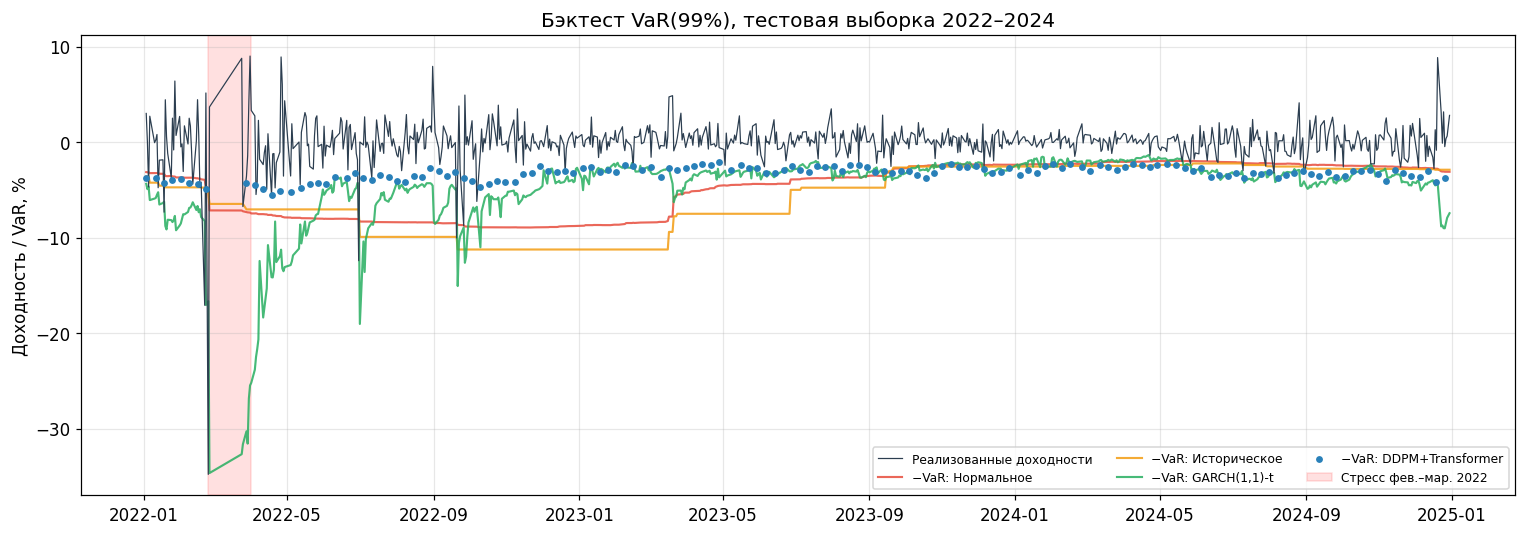

In [20]:
# ── График 1: VaR-бэктест ─────────────────────────────────────────────────
COLORS = {'normal': '#E74C3C', 'hist': '#F39C12', 'garch': '#27AE60', 'ddpm': '#2980B9'}
LABELS = {'normal': 'Нормальное', 'hist': 'Историческое',
          'garch': 'GARCH(1,1)-t', 'ddpm': 'DDPM+Transformer'}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_s.index, test_arr * 100, color='#2C3E50', lw=0.8,
        label='Реализованные доходности', zorder=3)

for key in ['normal', 'hist', 'garch']:
    ax.plot(test_s.index, -np.array(results[key]['var']) * 100,
            lw=1.4, color=COLORS[key], label=f'−VaR: {LABELS[key]}', alpha=0.85)

# Диффузию рисуем точками (т.к. считали каждые STEP дней)
ddpm_dates = test_s.index[results['ddpm']['idx']]
ax.scatter(ddpm_dates, -np.array(results['ddpm']['var']) * 100,
           s=12, color=COLORS['ddpm'], label=f'−VaR: {LABELS["ddpm"]}', zorder=4)

ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-04-01'),
           color='red', alpha=0.12, label='Стресс фев.–мар. 2022')
ax.set_ylabel('Доходность / VaR, %')
ax.set_title('Бэктест VaR(99%), тестовая выборка 2022–2024')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig('results/var_backtest.png', dpi=150)
plt.show()

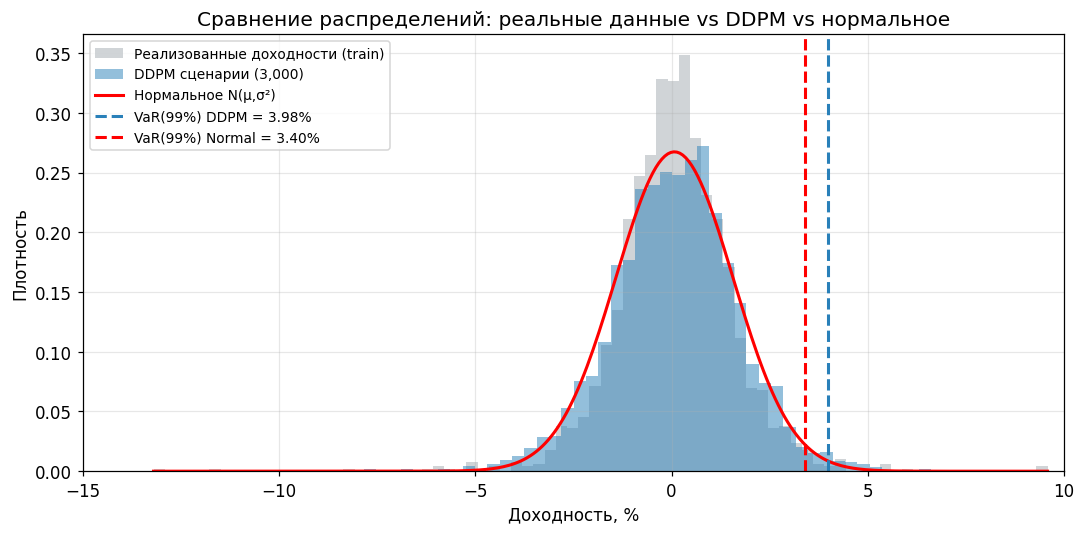

DDPM сценарии: mean=0.086%  std=1.661%  kurt=3.64  VaR(99%)=3.98%
Реальные:      mean=0.072%  std=1.491%  kurt=8.46


In [21]:
# ── График 2: Распределение — факт vs DDPM vs нормальное ──────────────────
ctx_last   = train_arr[-W:]
scenarios  = generate_scenarios(ctx_last, n=3000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_arr * 100, bins=80, density=True, color='#BDC3C7', alpha=0.7,
        label='Реализованные доходности (train)')
ax.hist(scenarios * 100,  bins=80, density=True, color='#2980B9', alpha=0.5,
        label=f'DDPM сценарии ({len(scenarios):,})')
x = np.linspace(train_arr.min()*100, train_arr.max()*100, 300)
ax.plot(x, stats.norm.pdf(x, train_arr.mean()*100, train_arr.std()*100),
        'r-', lw=2, label='Нормальное N(μ,σ²)')

# Отмечаем VaR
var_ddpm = np.quantile(-scenarios, ALPHA)
var_norm, _ = var_cvar_normal(train_arr)
ax.axvline(var_ddpm * 100,  color='#2980B9', ls='--', lw=2,
           label=f'VaR(99%) DDPM = {var_ddpm*100:.2f}%')
ax.axvline(var_norm * 100,  color='red',     ls='--', lw=2,
           label=f'VaR(99%) Normal = {var_norm*100:.2f}%')

ax.set_xlabel('Доходность, %')
ax.set_ylabel('Плотность')
ax.set_title('Сравнение распределений: реальные данные vs DDPM vs нормальное')
ax.legend(fontsize=9)
ax.set_xlim(-15, 10)
plt.tight_layout()
plt.savefig('results/distribution_comparison.png', dpi=150)
plt.show()

print(f'DDPM сценарии: mean={scenarios.mean()*100:.3f}%  '
      f'std={scenarios.std()*100:.3f}%  '
      f'kurt={stats.kurtosis(scenarios):.2f}  '
      f'VaR(99%)={var_ddpm*100:.2f}%')
print(f'Реальные:      mean={train_arr.mean()*100:.3f}%  '
      f'std={train_arr.std()*100:.3f}%  '
      f'kurt={stats.kurtosis(train_arr):.2f}')

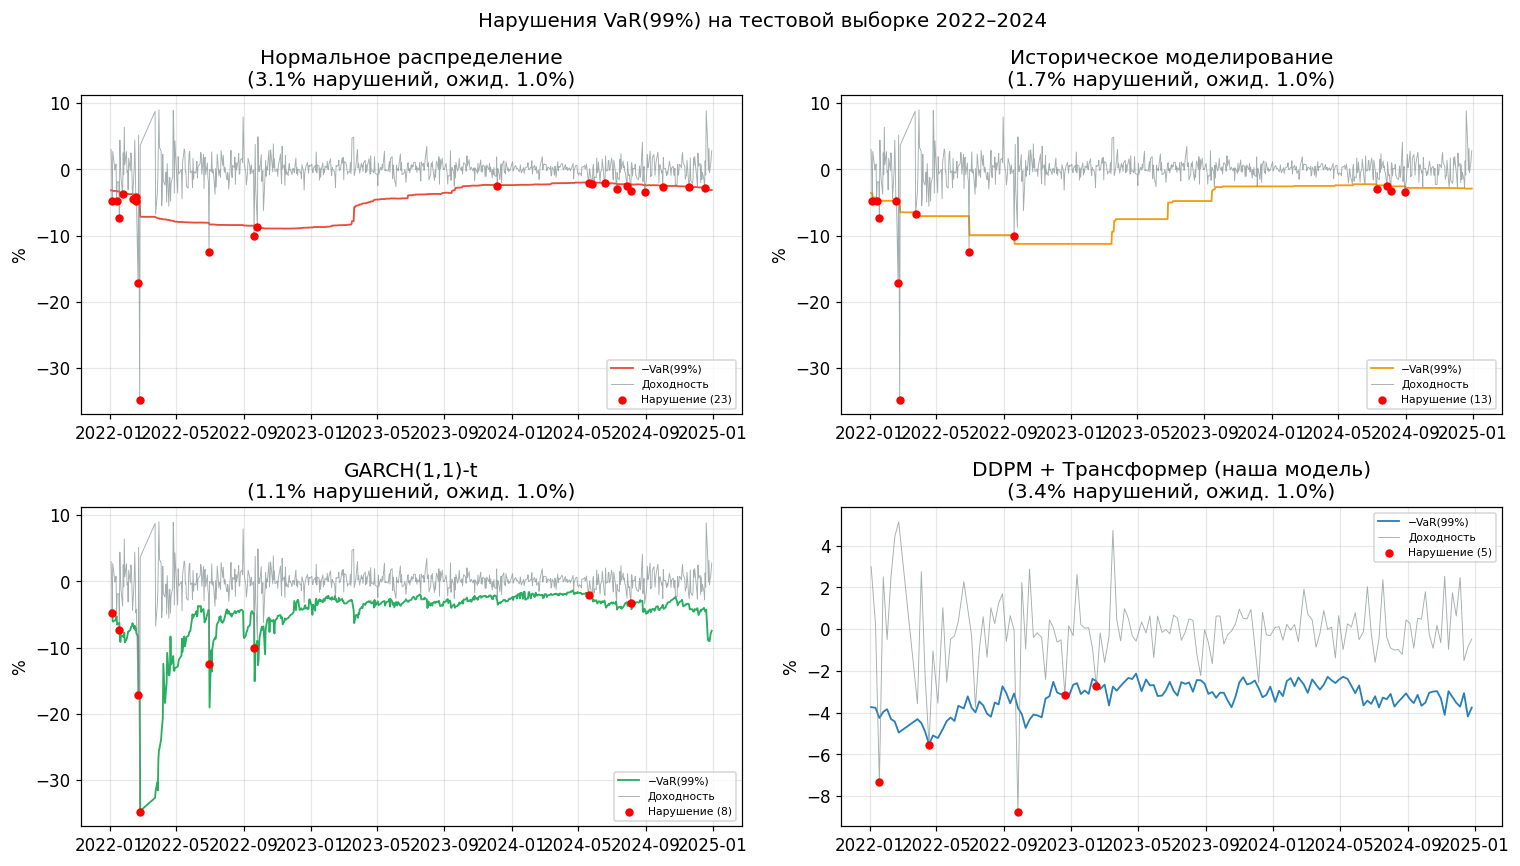

In [22]:
# ── График 3: Нарушения VaR по месяцам (диффузия vs GARCH) ───────────────
# Строим только для baseline (каждый день), т.к. диффузия каждые STEP дней
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (key, name) in zip(axes.flat, NAMES.items()):
    idx_list = results[key]['idx']
    var_arr  = np.array(results[key]['var'])
    act_arr  = test_arr[idx_list]
    dates    = test_s.index[idx_list]
    violations = (-act_arr > var_arr)

    ax.plot(dates, -var_arr * 100, color=COLORS[key], lw=1.2, label='−VaR(99%)')
    ax.plot(dates, act_arr * 100,  color='#7F8C8D',   lw=0.6, alpha=0.7, label='Доходность')
    ax.scatter(dates[violations], act_arr[violations] * 100,
               color='red', s=20, zorder=5, label=f'Нарушение ({violations.sum()})')
    ax.set_title(f'{name}\n({violations.mean()*100:.1f}% нарушений, ожид. 1.0%)')
    ax.set_ylabel('%')
    ax.legend(fontsize=7)

plt.suptitle('Нарушения VaR(99%) на тестовой выборке 2022–2024', fontsize=13)
plt.tight_layout()
plt.savefig('results/violations_by_method.png', dpi=150)
plt.show()

## 12. Итоги

Сводная таблица и основные выводы по результатам эксперимента.

In [23]:
print('\n' + '='*70)
print('ИТОГИ ЭКСПЕРИМЕНТА')
print('='*70)
print(f'Данные: портфель {TICKERS}, {len(train_arr)} дней train / {len(test_arr)} дней test')
print(f'Уровень доверия: α = {ALPHA}')
print(f'Архитектура DDPM: T={T_DIFF}, W={W}, d={D_MODEL}, layers={N_LAYERS}, heads={N_HEADS}')
print()
print(summary_df.to_string(index=False))
print()
print('Интерпретация:')
print('  • Нарушений должно быть ~1.0% (для α=99%)')
print('  • Тест Купика H0 "не отклоняется" → модель корректно калибрована')
print('  • Меньший Tick loss → лучше')
print()
print(f'Параметров модели: {n_params:,}')
print(f'Best val loss: {best_val:.5f}')


ИТОГИ ЭКСПЕРИМЕНТА
Данные: портфель ['SBER', 'LKOH', 'GAZP'], 1764 дней train / 744 дней test
Уровень доверия: α = 0.99
Архитектура DDPM: T=200, W=30, d=32, layers=2, heads=4

                           Метод  VaR(99%) mean, %  Нарушений, %  Tick loss       Тест Купика  p-value
        Нормальное распределение             4.769          3.09    0.04775    H0 отклоняется   0.0000
      Историческое моделирование             5.720          1.75    0.05707 H0 не отклоняется   0.0639
                    GARCH(1,1)-t             4.649          1.08    0.04629 H0 не отклоняется   0.8385
DDPM + Трансформер (наша модель)             3.263          3.36    0.03194    H0 отклоняется   0.0230

Интерпретация:
  • Нарушений должно быть ~1.0% (для α=99%)
  • Тест Купика H0 "не отклоняется" → модель корректно калибрована
  • Меньший Tick loss → лучше

Параметров модели: 31,969
Best val loss: 0.44468


## 13. Архитектура модели — torchinfo + Netron

*(Добавлено для Задания 6П)*

Вывод `torchinfo` показывает каждый слой, размерности тензоров и число параметров.  
ONNX-экспорт позволяет визуализировать граф модели в **[Netron](https://netron.app)**.

In [18]:
from torchinfo import summary as ti_summary

# Тестовые входы (batch=1 для наглядного вывода)
_xt  = torch.randn(1, 1, device=DEVICE)
_t   = torch.randint(0, T_DIFF, (1,), device=DEVICE)
_ctx = torch.randn(1, W, device=DEVICE)

print('=' * 70)
print('TransformerDenoiser — torchinfo summary')
print(f'd_model={D_MODEL}, n_heads={N_HEADS}, n_layers={N_LAYERS}, '
      f'd_ff={D_FF}, W={W}, T={T_DIFF}')
print('=' * 70)

model_info = ti_summary(
    model,
    input_data=(_xt, _t, _ctx),
    col_names=['input_size', 'output_size', 'num_params', 'trainable'],
    col_width=20,
    depth=4,
    verbose=1,
)

# Сохраняем для README
os.makedirs('assets', exist_ok=True)
with open('assets/torchinfo_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(model_info))
print('\nСохранено: assets/torchinfo_summary.txt')


TransformerDenoiser — torchinfo summary
d_model=32, n_heads=4, n_layers=2, d_ff=128, W=30, T=200
Layer (type:depth-idx)                        Input Shape          Output Shape         Param #              Trainable
TransformerDenoiser                           [1, 1]               [1, 1]               --                   True
├─Linear: 1-1                                 [1, 31, 1]           [1, 31, 32]          64                   True
├─Embedding: 1-2                              [1]                  [1, 32]              6,400                True
├─TransformerEncoder: 1-3                     [1, 31, 32]          [1, 31, 32]          --                   True
│    └─ModuleList: 2-1                        --                   --                   --                   True
│    │    └─TransformerEncoderLayer: 3-1      [1, 31, 32]          [1, 31, 32]          --                   True
│    │    │    └─LayerNorm: 4-1               [1, 31, 32]          [1, 31, 32]          64          

In [19]:
# Экспорт в ONNX для визуализации в Netron (https://netron.app)
model.eval()
onnx_path = 'assets/model.onnx'

torch.onnx.export(
    model,
    (_xt, _t, _ctx),
    onnx_path,
    input_names=['x_t', 'diffusion_step', 'context'],
    output_names=['predicted_noise'],
    dynamic_axes={
        'x_t':             {0: 'batch'},
        'diffusion_step':  {0: 'batch'},
        'context':         {0: 'batch'},
        'predicted_noise': {0: 'batch'},
    },
    opset_version=17,
    verbose=False,
)

print(f'✅ ONNX-граф сохранён: {onnx_path}')
print()
print('Дальнейшие шаги:')
print('  1. Скачайте файл assets/model.onnx')
print('  2. Откройте https://netron.app')
print('  3. Перетащите model.onnx в браузер')
print('  4. Сделайте скриншот → сохраните как assets/netron_screenshot.png')
print('  5. README.md уже содержит ссылку на этот файл')


ModuleNotFoundError: No module named 'onnxscript'